# 2. Visualize CSV

Load **all** channel occupancy and frequency legend CSVs from **`work_dir/csvs`** and plot **channel occupancy over time** (heatmap) and **airtime utilization** (bar chart) for each Data file.

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
from datetime import datetime, timezone
import matplotlib.pyplot as plt

In [10]:
# Base path: work_dir/csvs (try cwd, then parent so it works from repo root or notebooks/)
csvs_dir = Path("work_dir/csvs")
if not csvs_dir.exists():
    csvs_dir = Path("..") / "work_dir" / "csvs"
occupancy_dir = csvs_dir / "channel_occupancy"
legend_dir = csvs_dir / "frequency_legends"

# Load all Data_*.csv files (set max_plots to cap how many figures to draw, or None for all)
data_files = sorted(occupancy_dir.glob("Data_*.csv")) if occupancy_dir.exists() else []
max_plots = None  # e.g. 24 to limit; None = all
to_plot = (data_files[:max_plots] if max_plots is not None else data_files) if data_files else []

if not data_files:
    print("No Data_*.csv files in", occupancy_dir)
else:
    print(f"Found {len(data_files)} Data file(s). Visualizing {len(to_plot)}.")

Found 23 Data file(s). Visualizing 23.


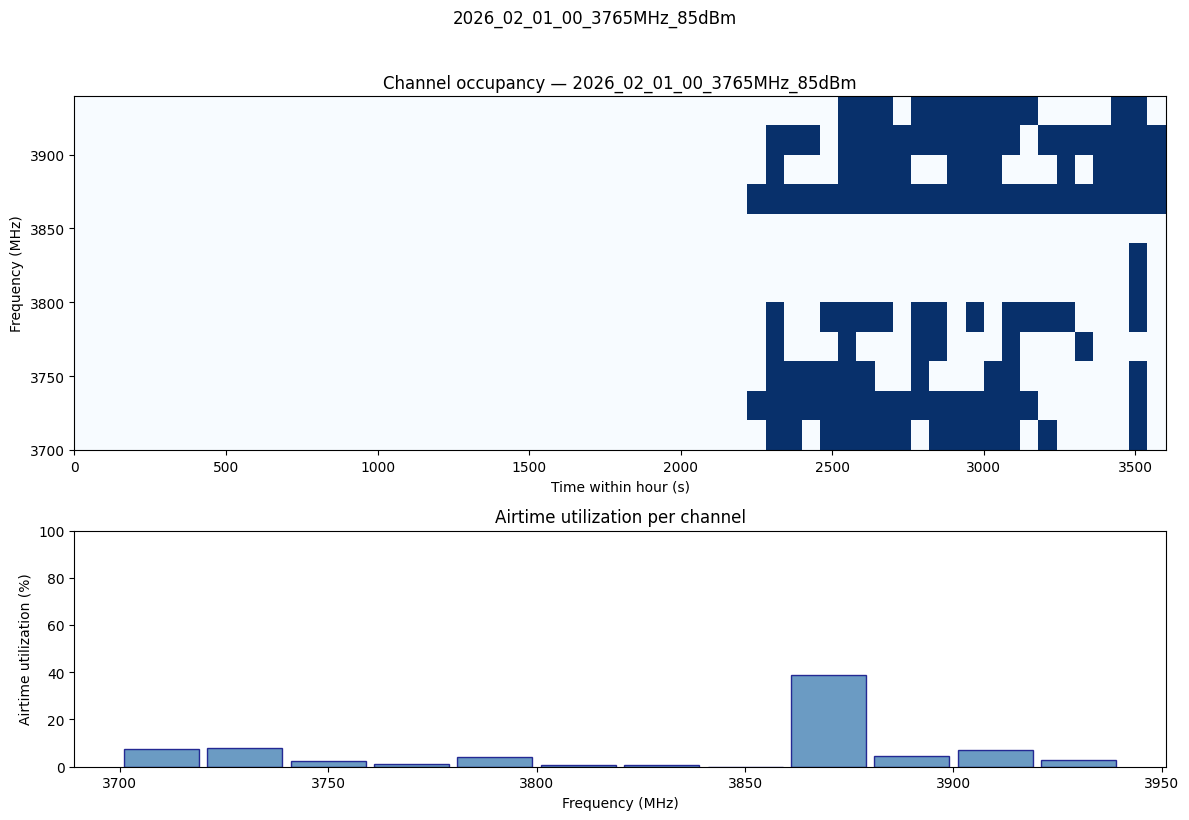

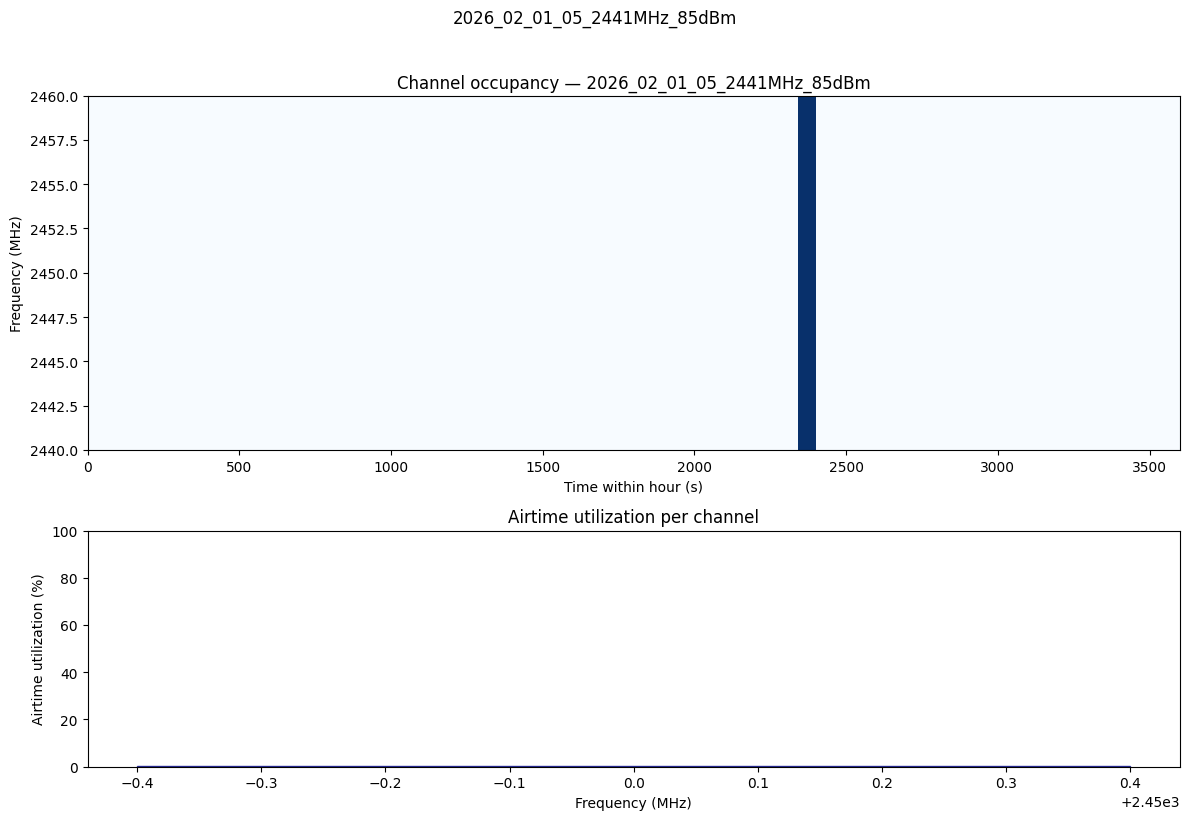

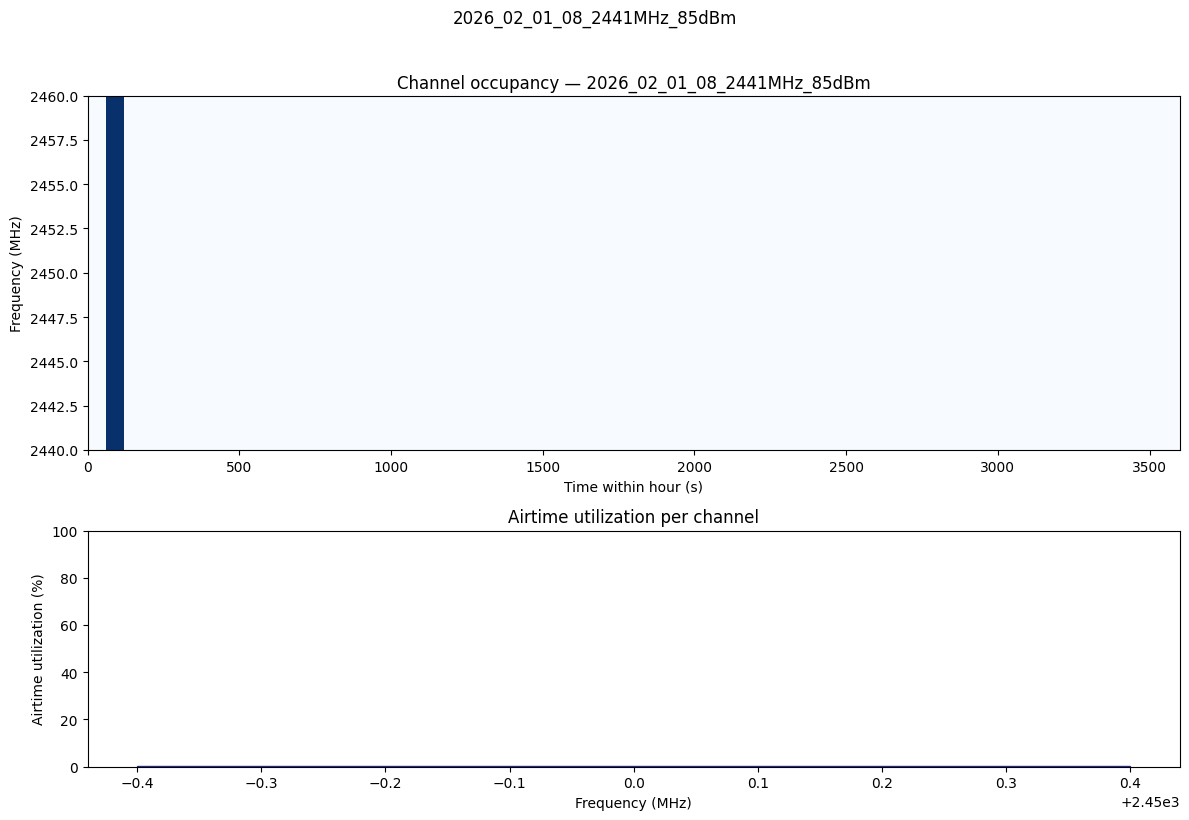

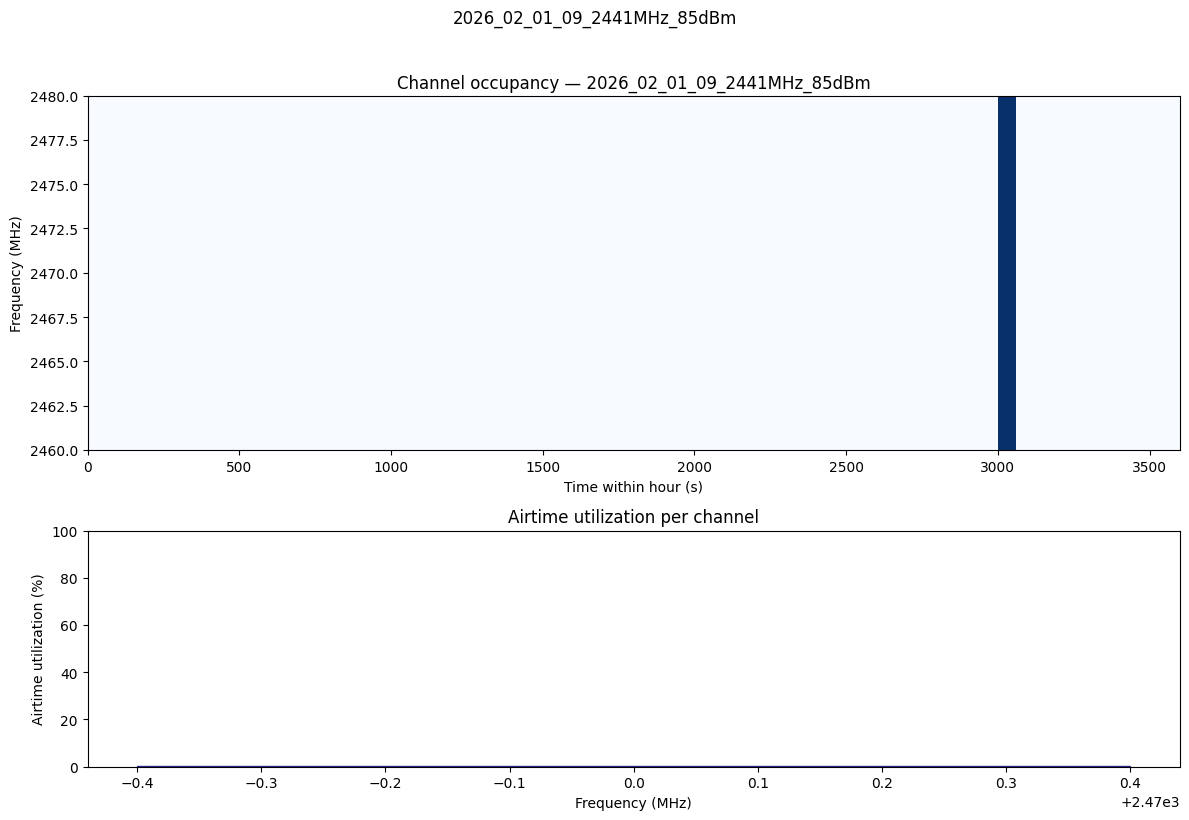

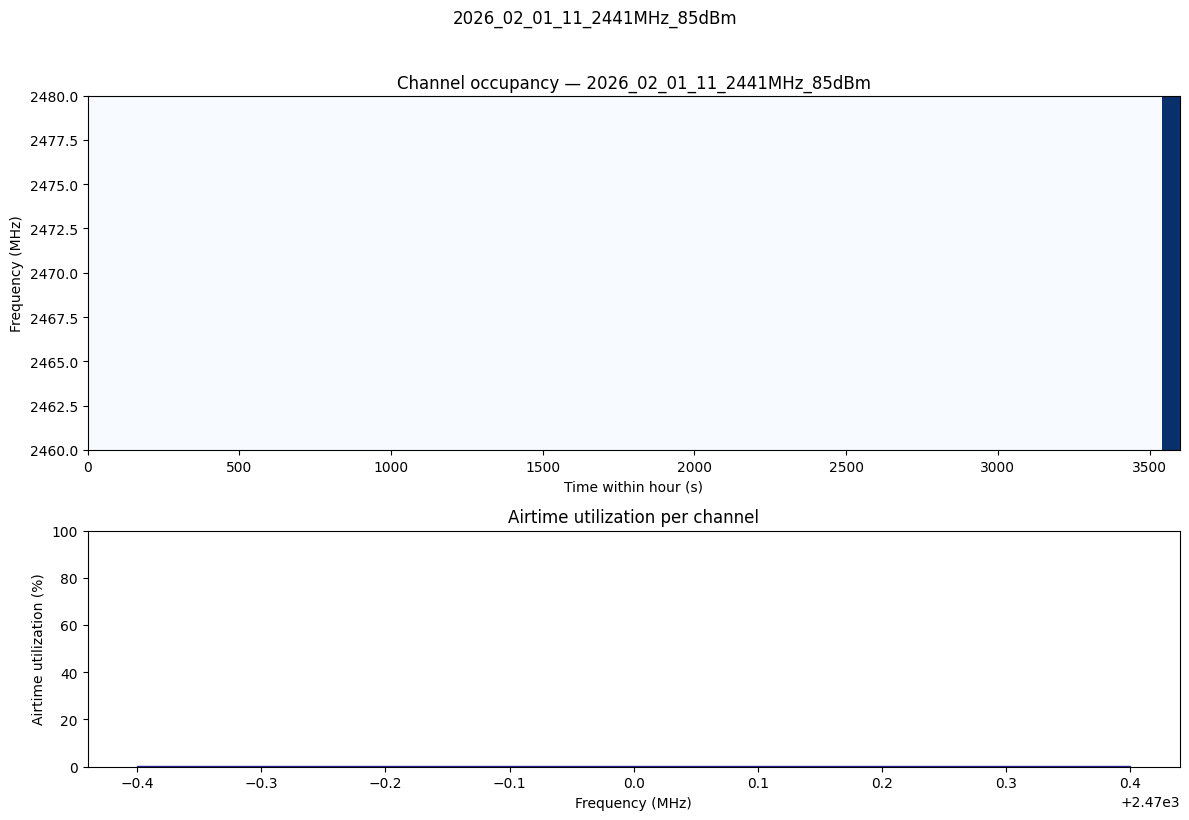

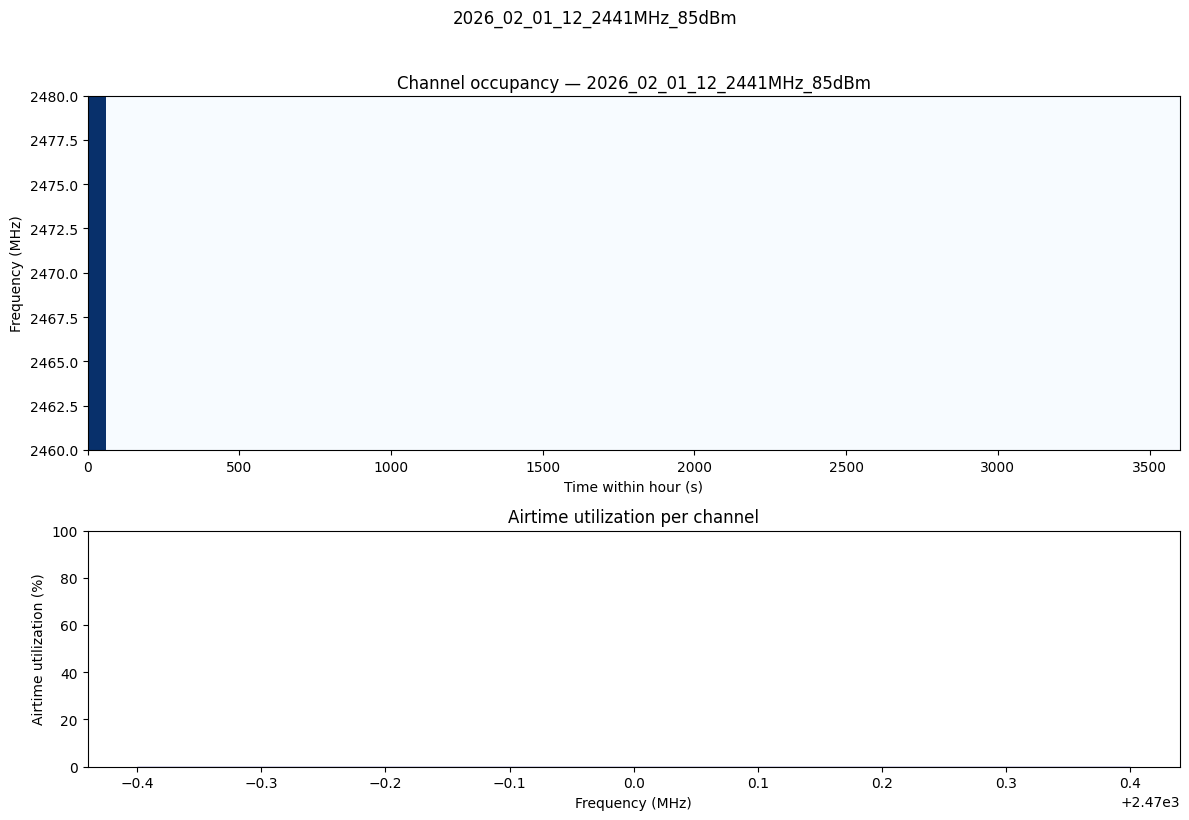

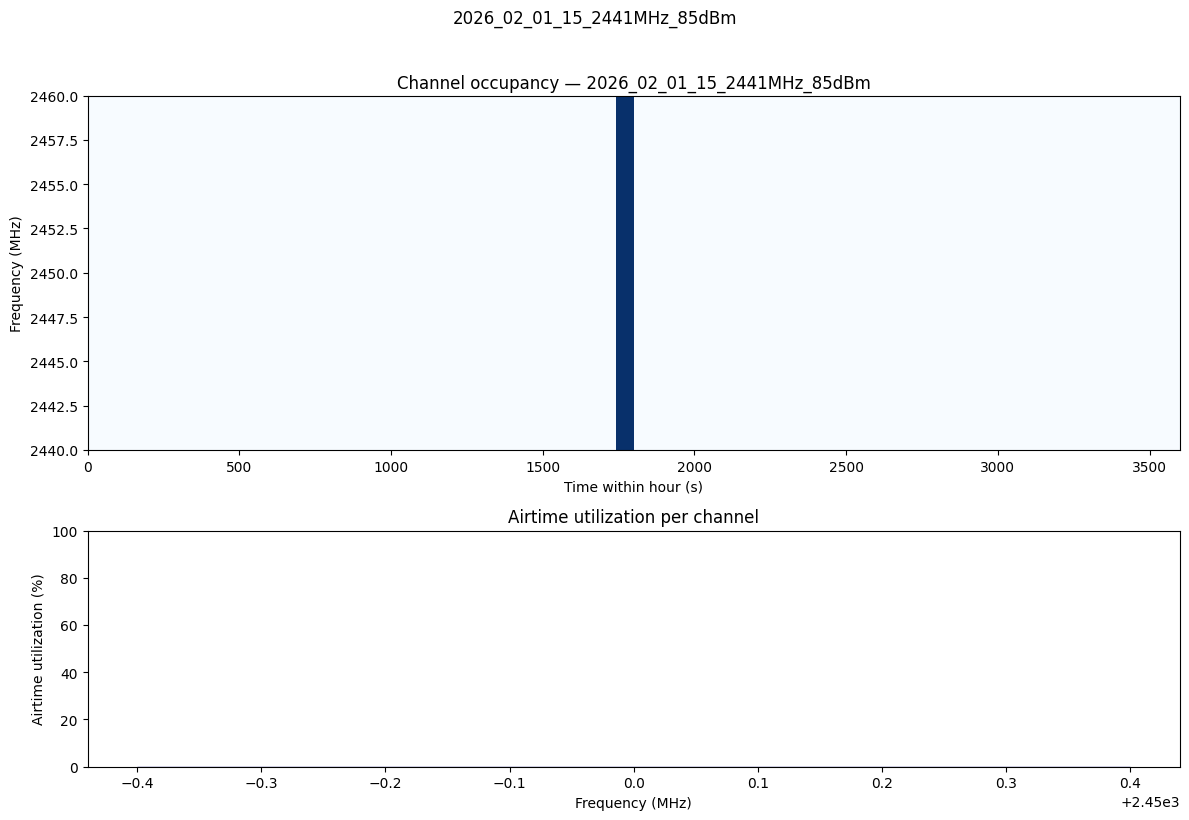

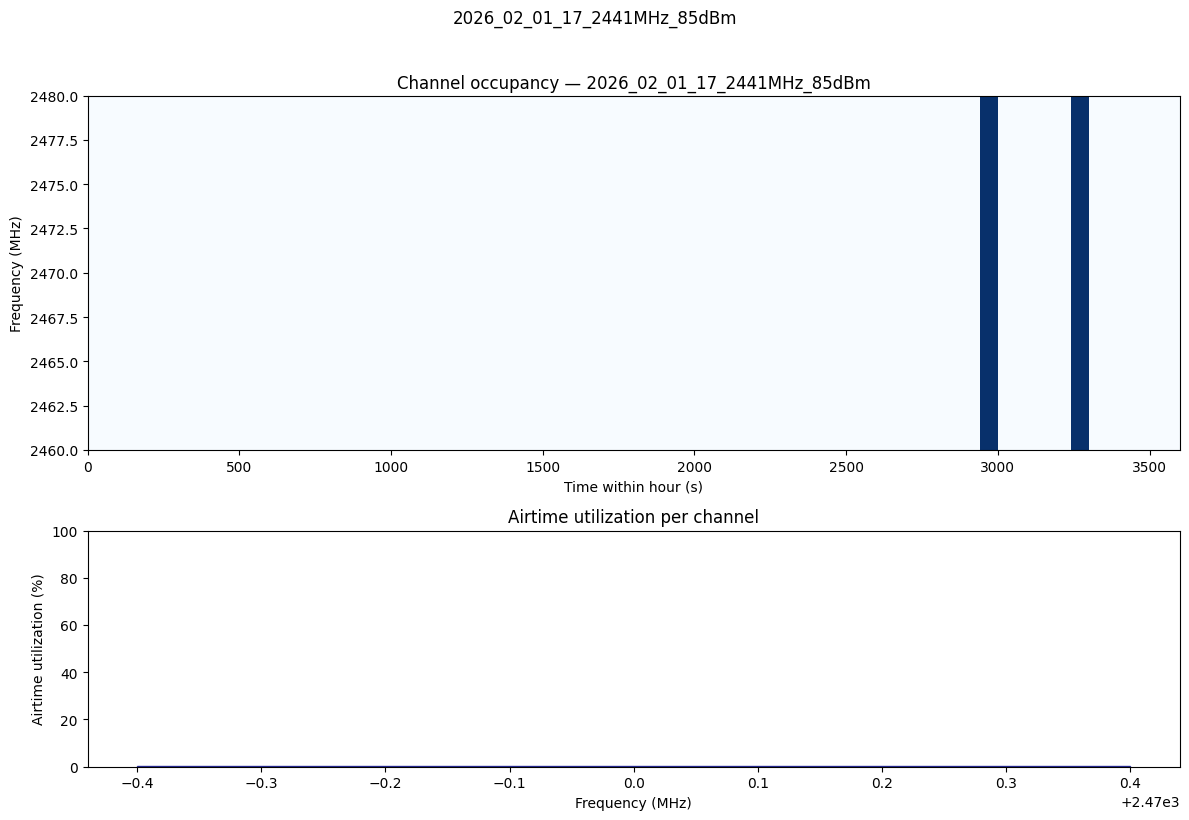

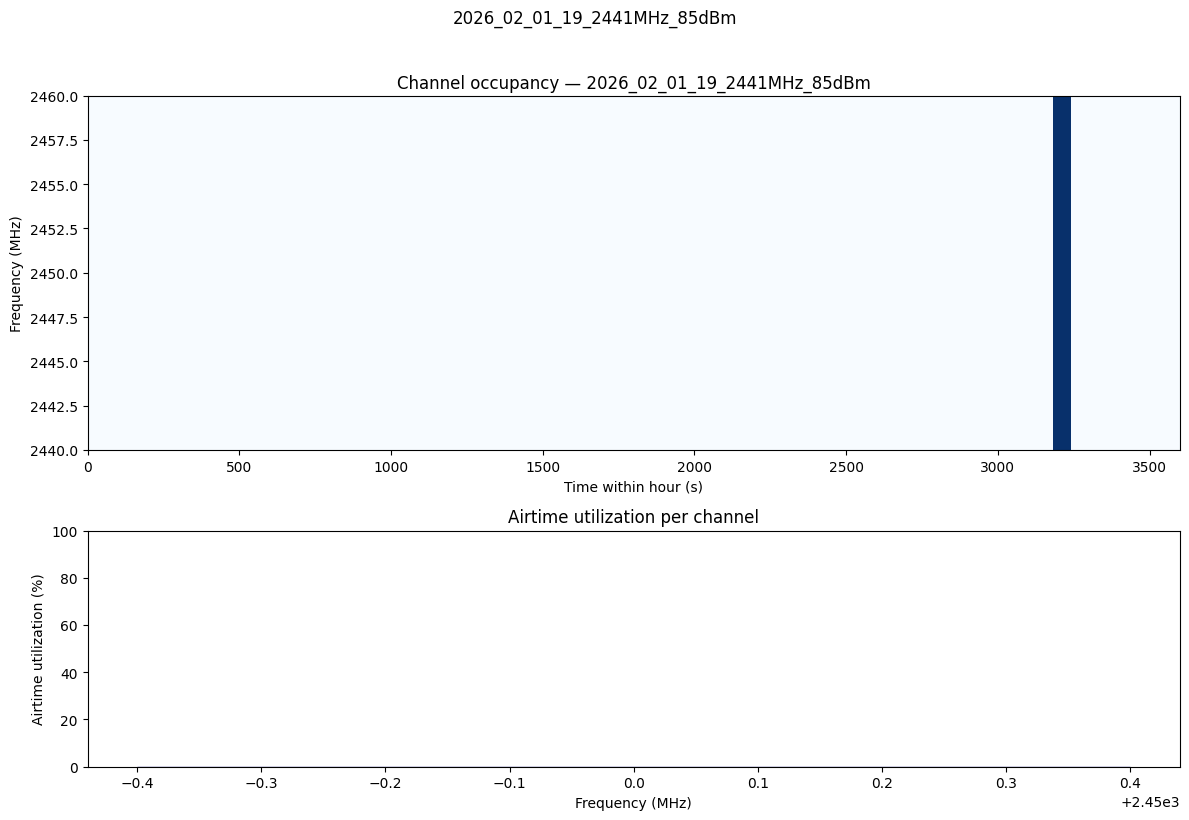

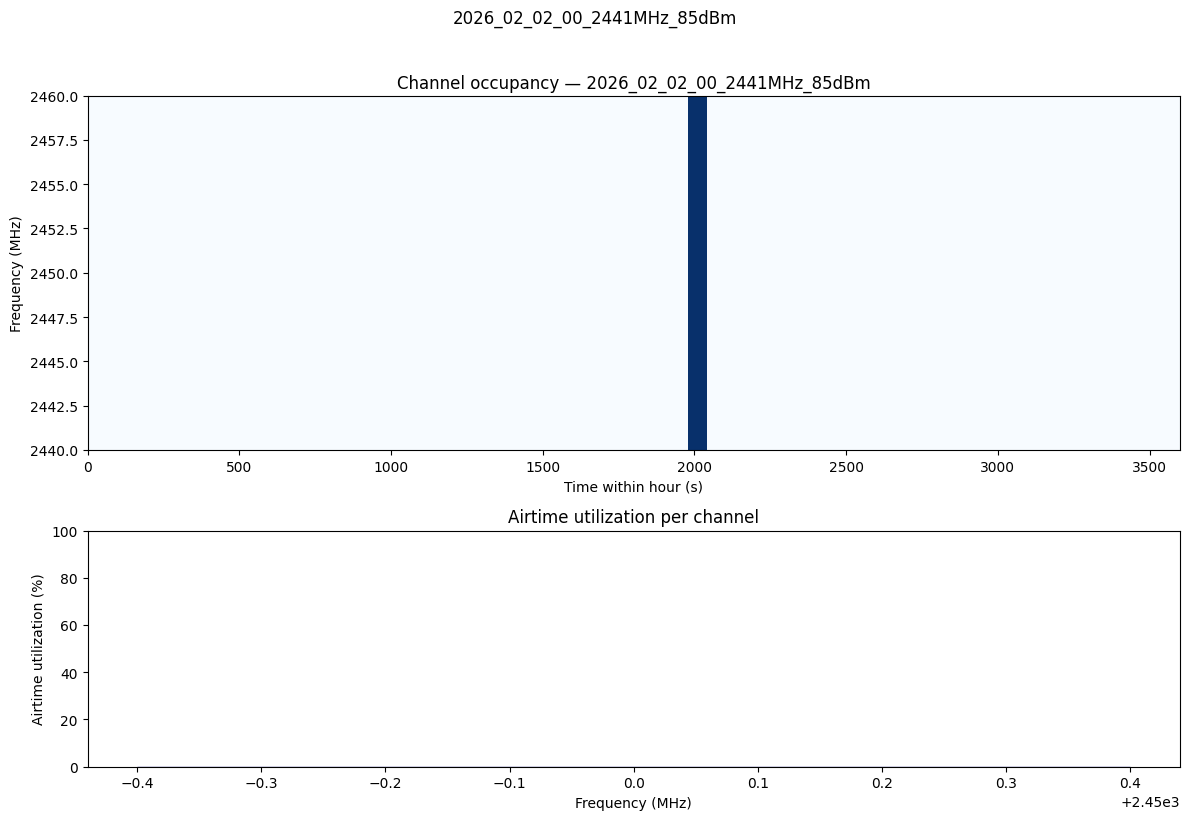

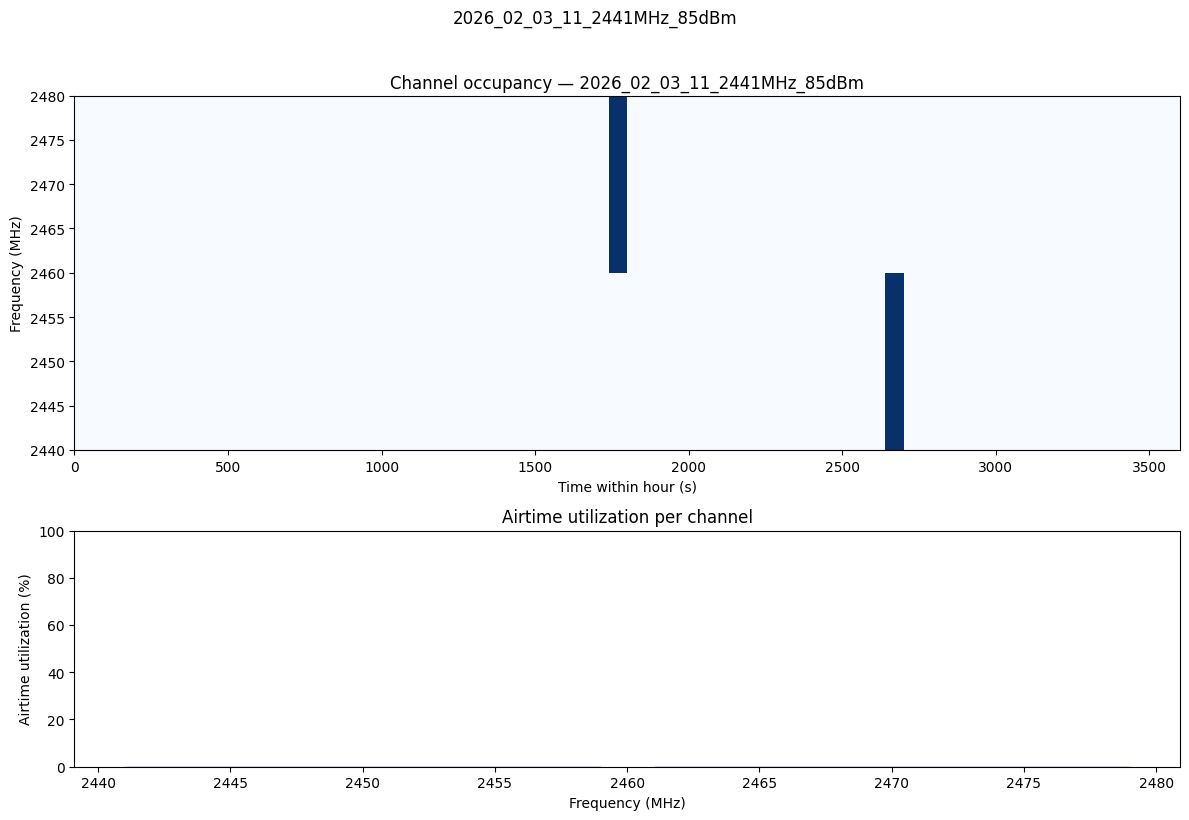

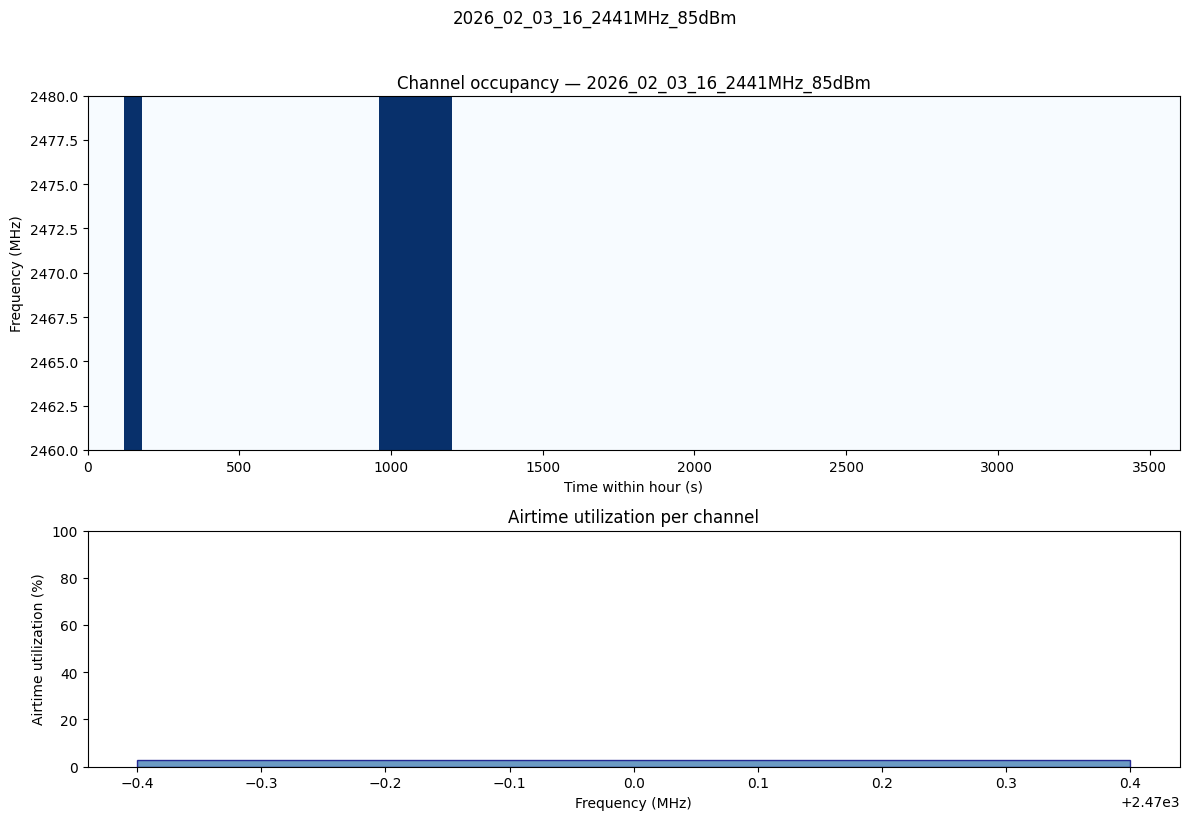

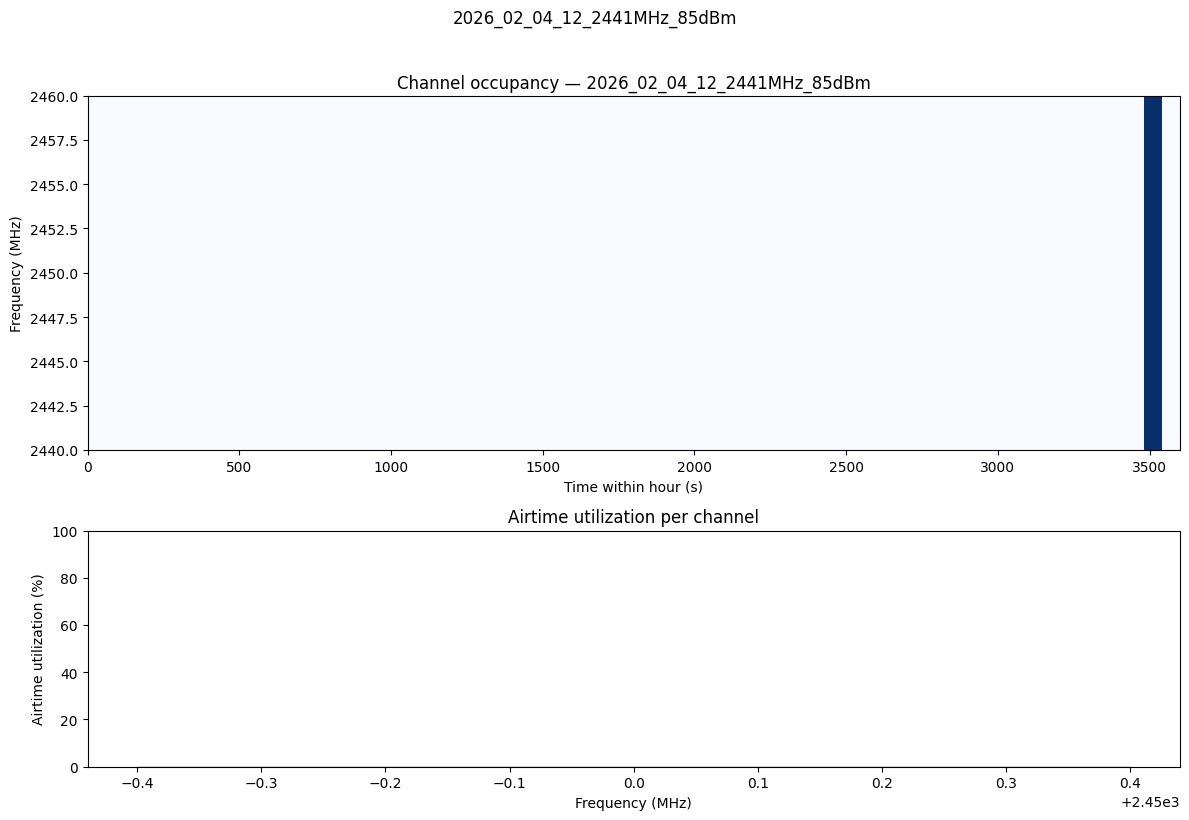

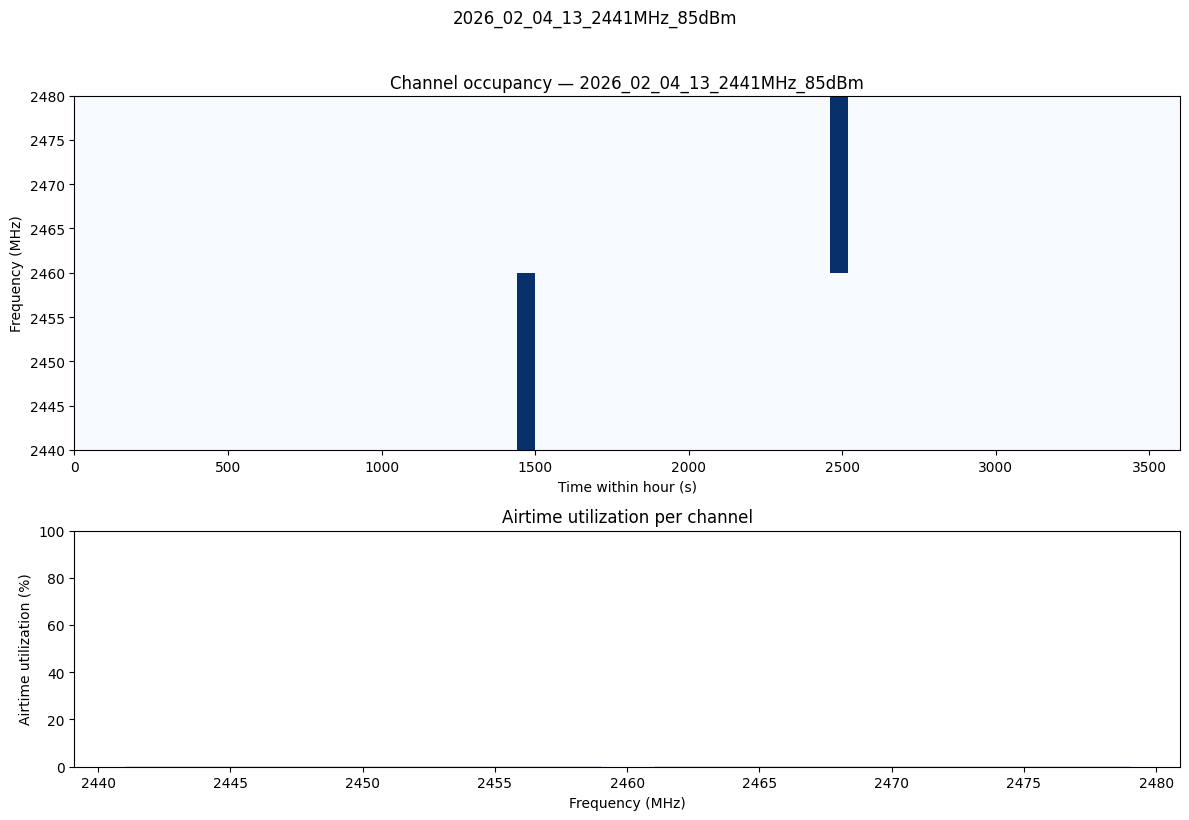

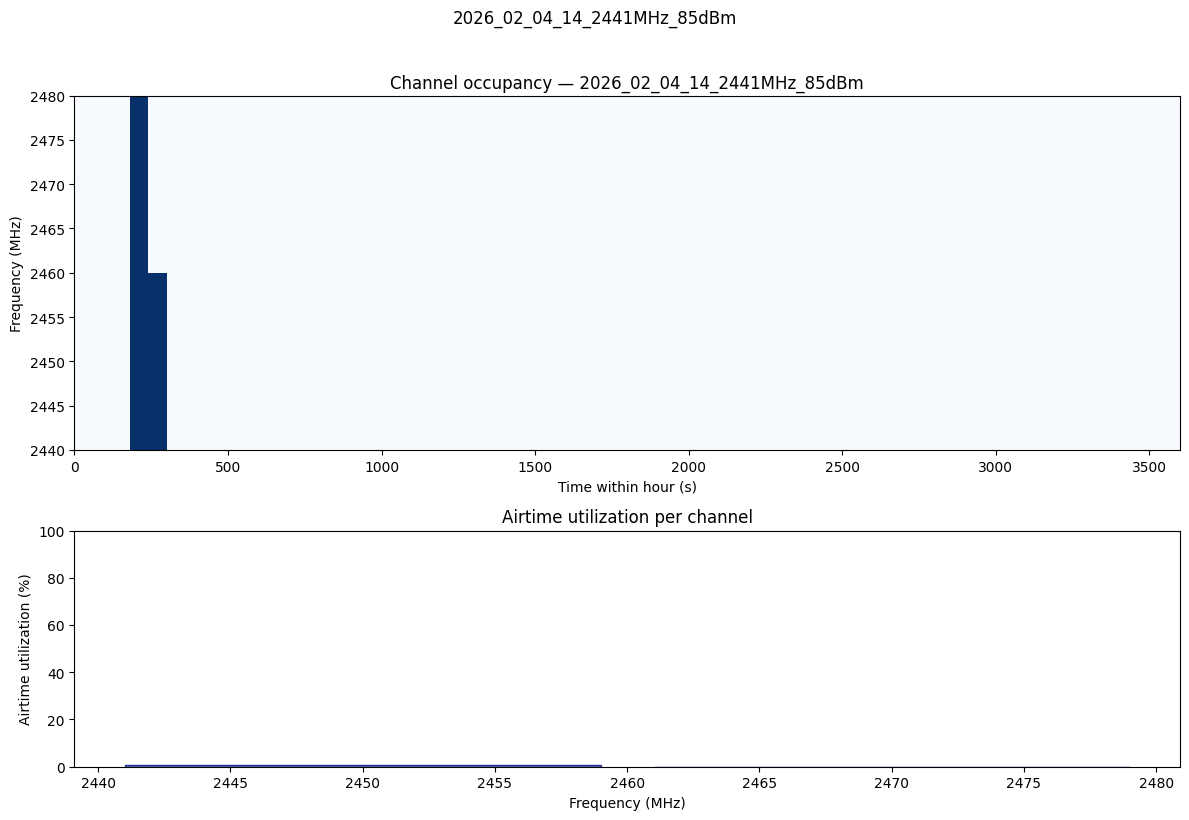

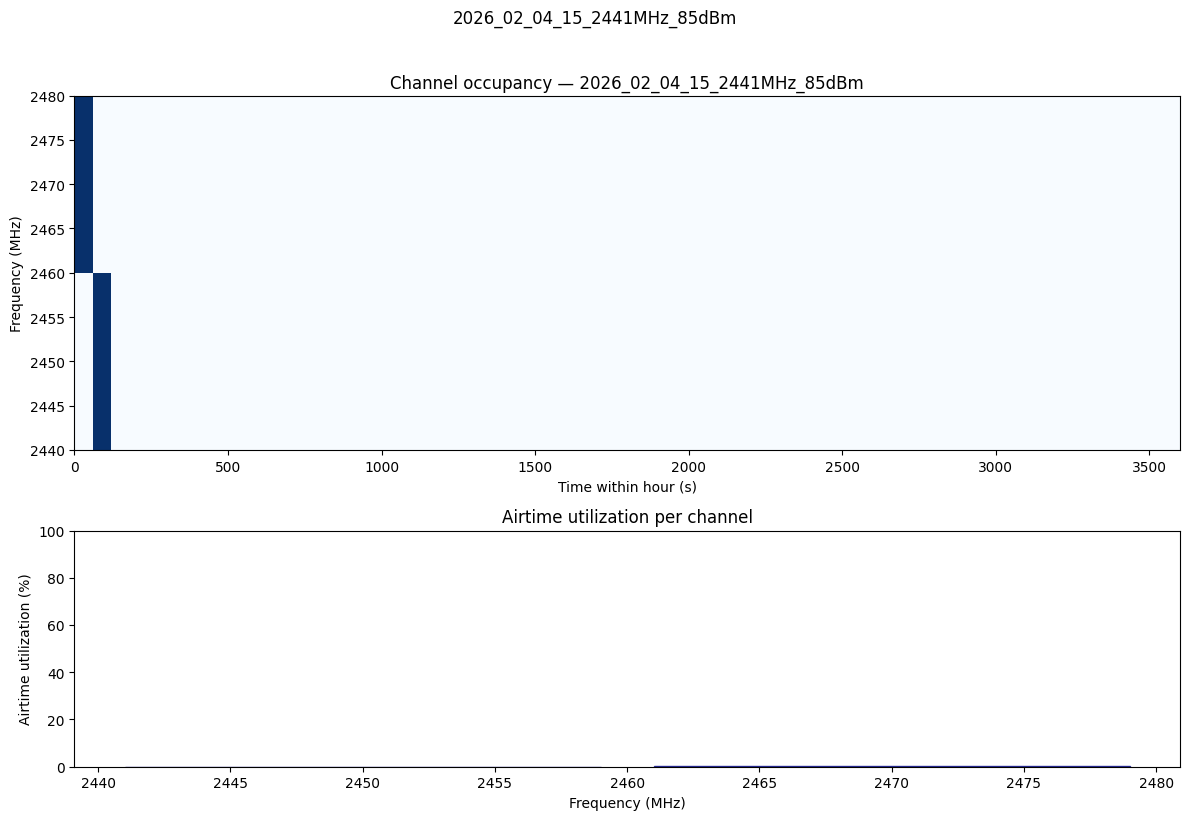

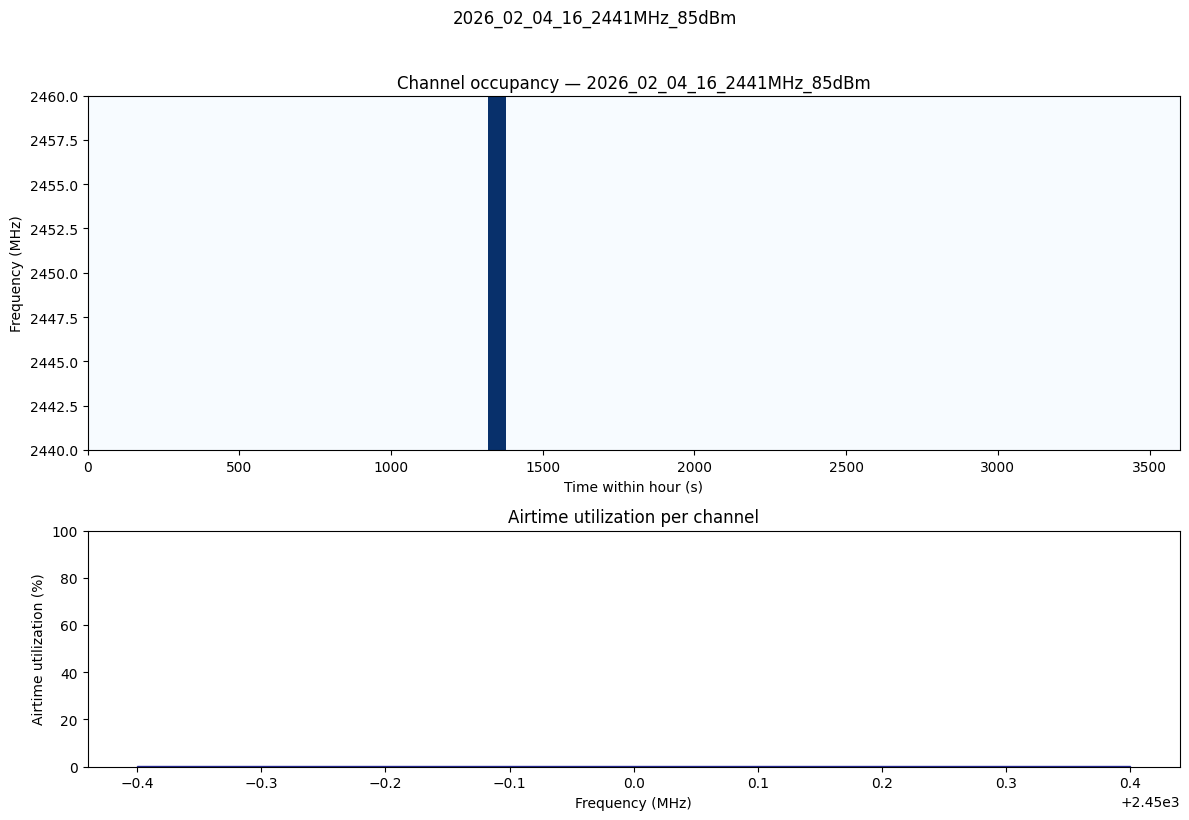

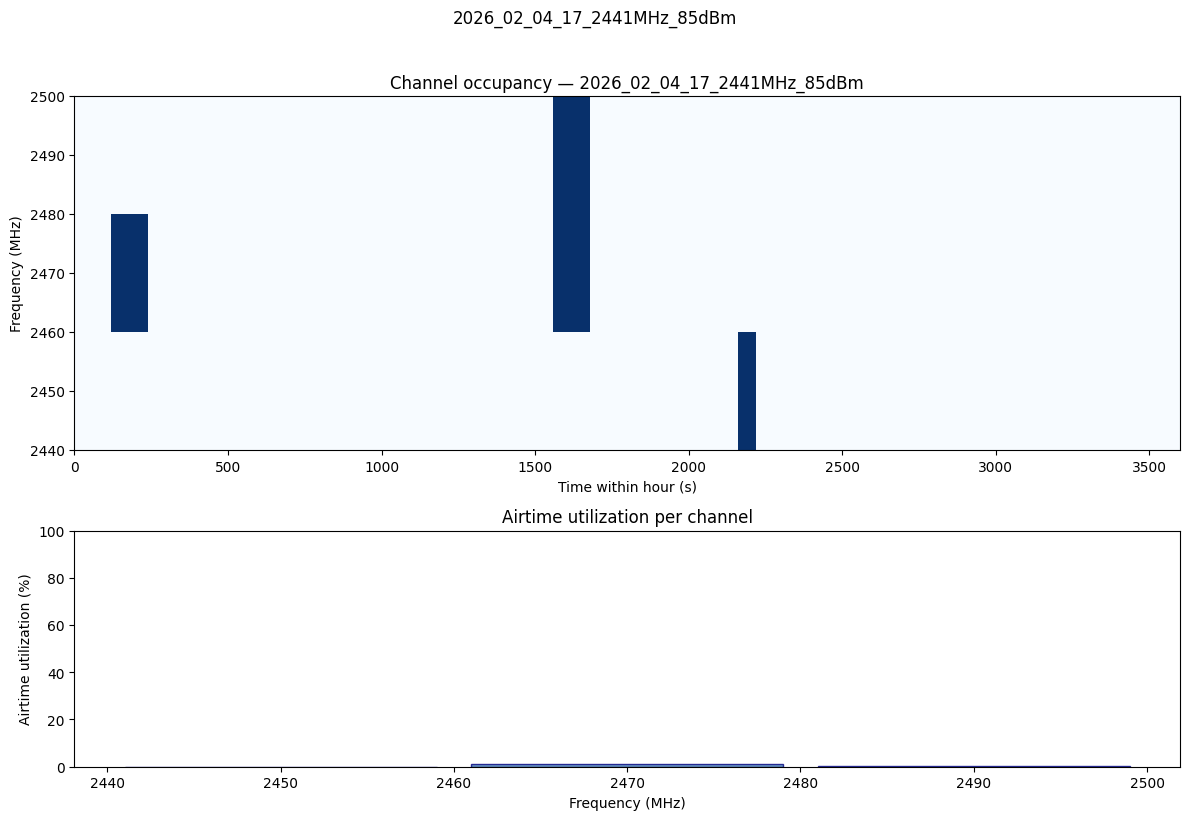

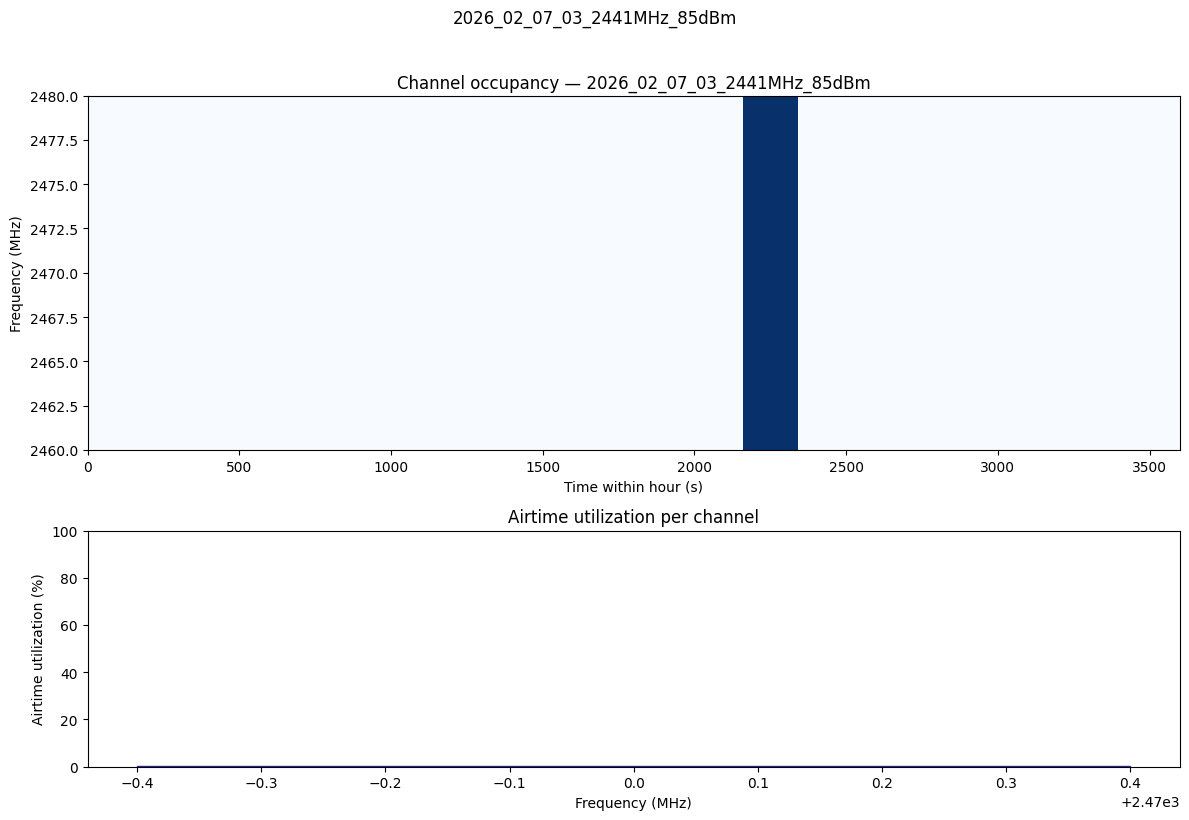

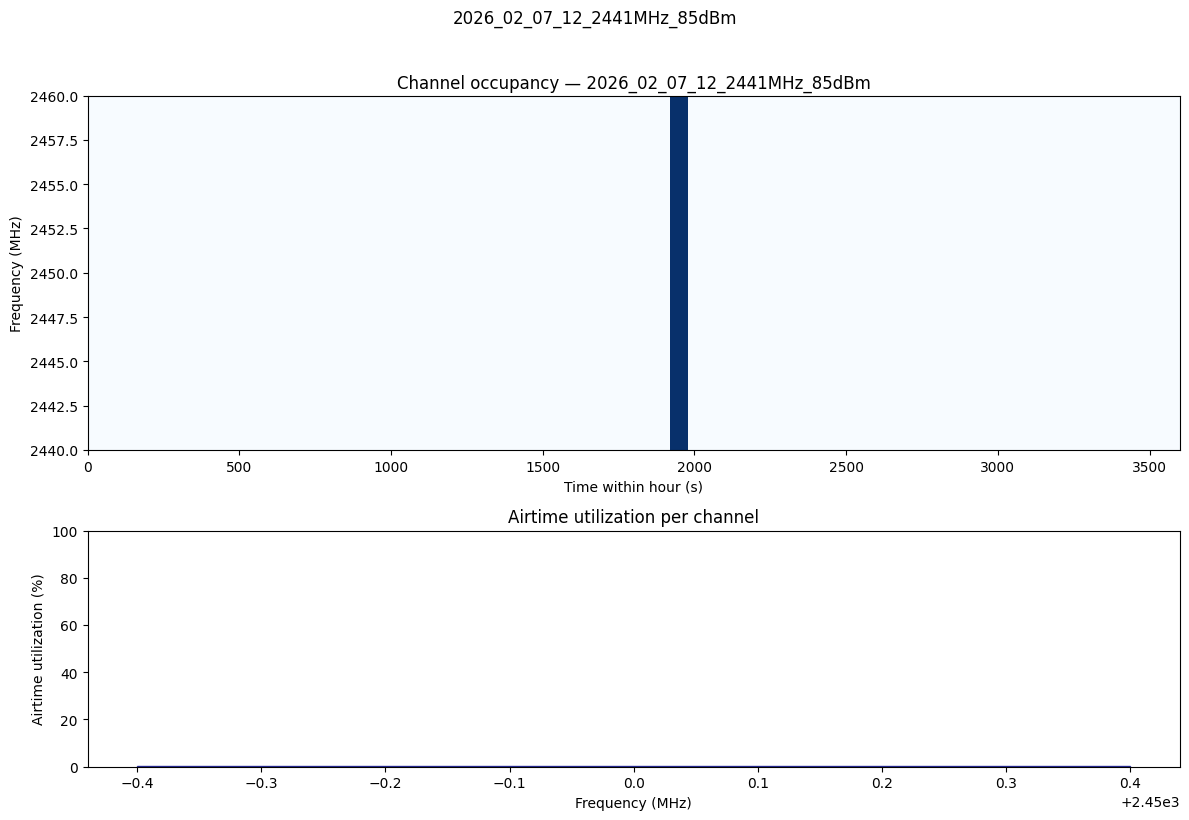

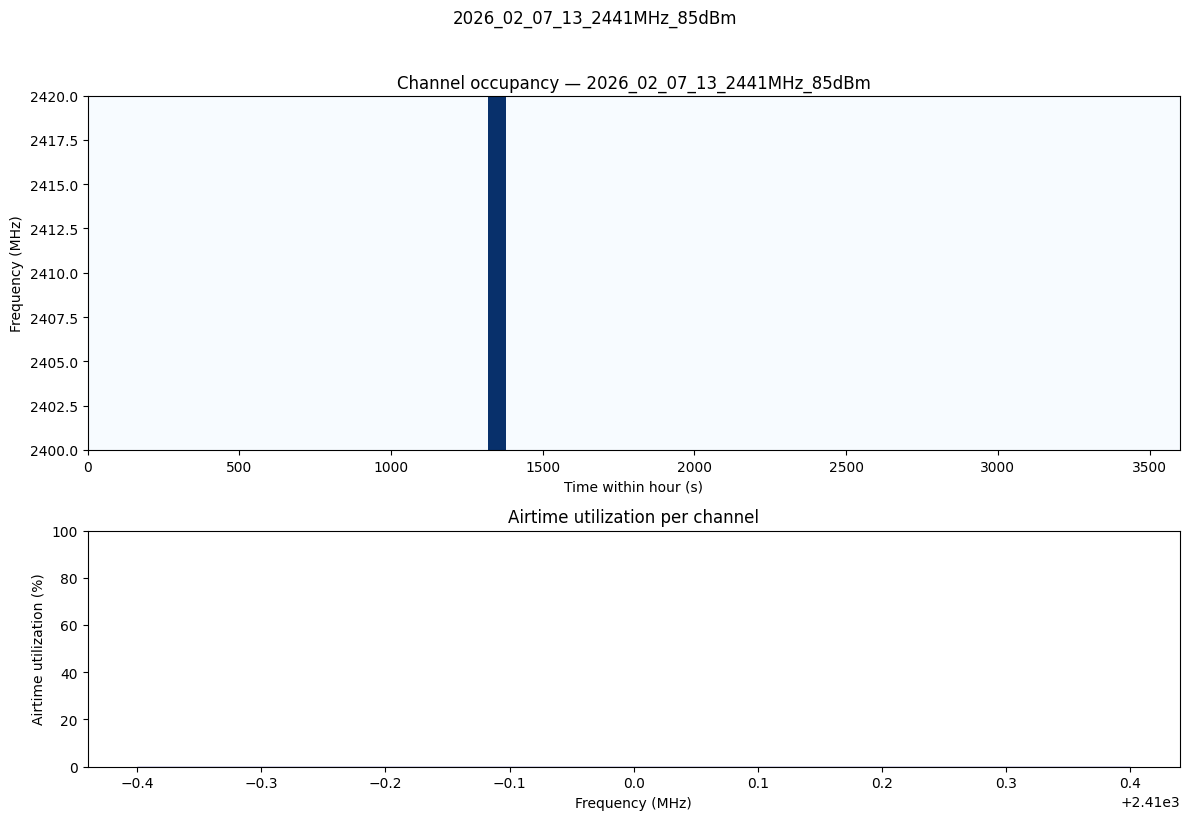

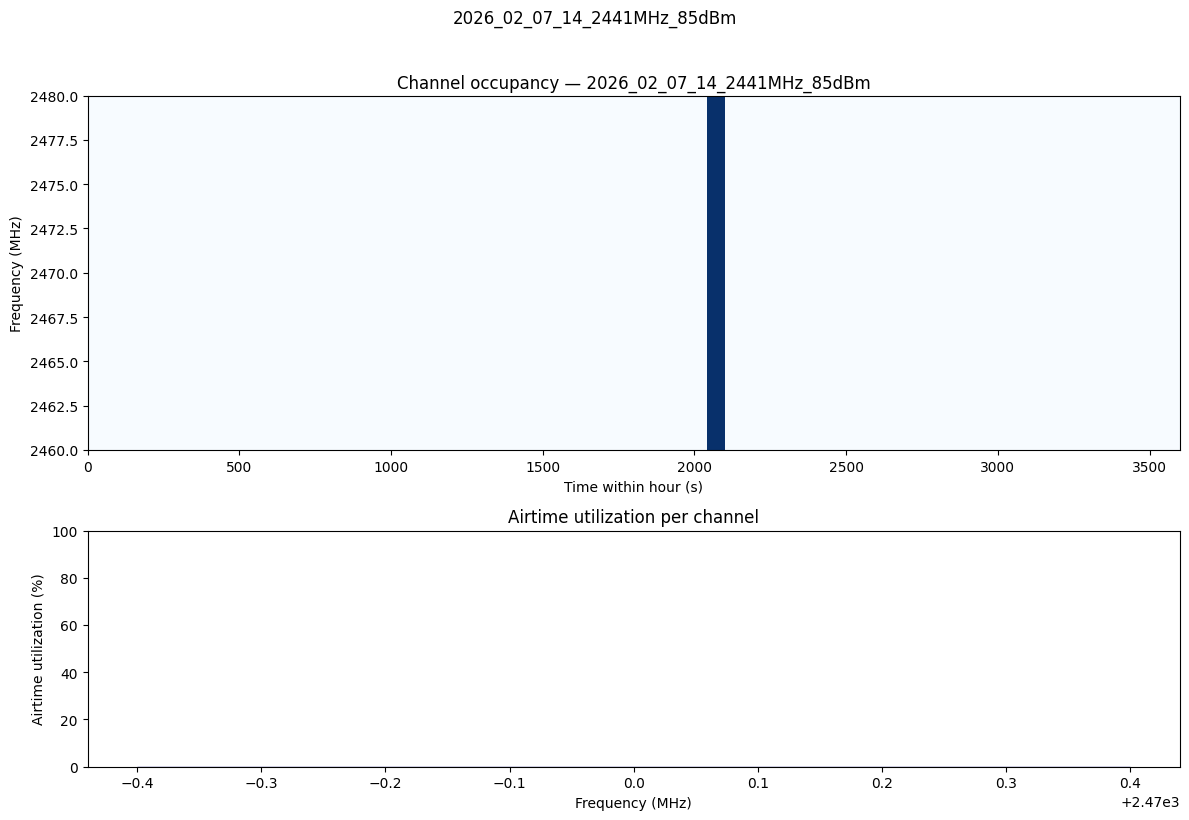

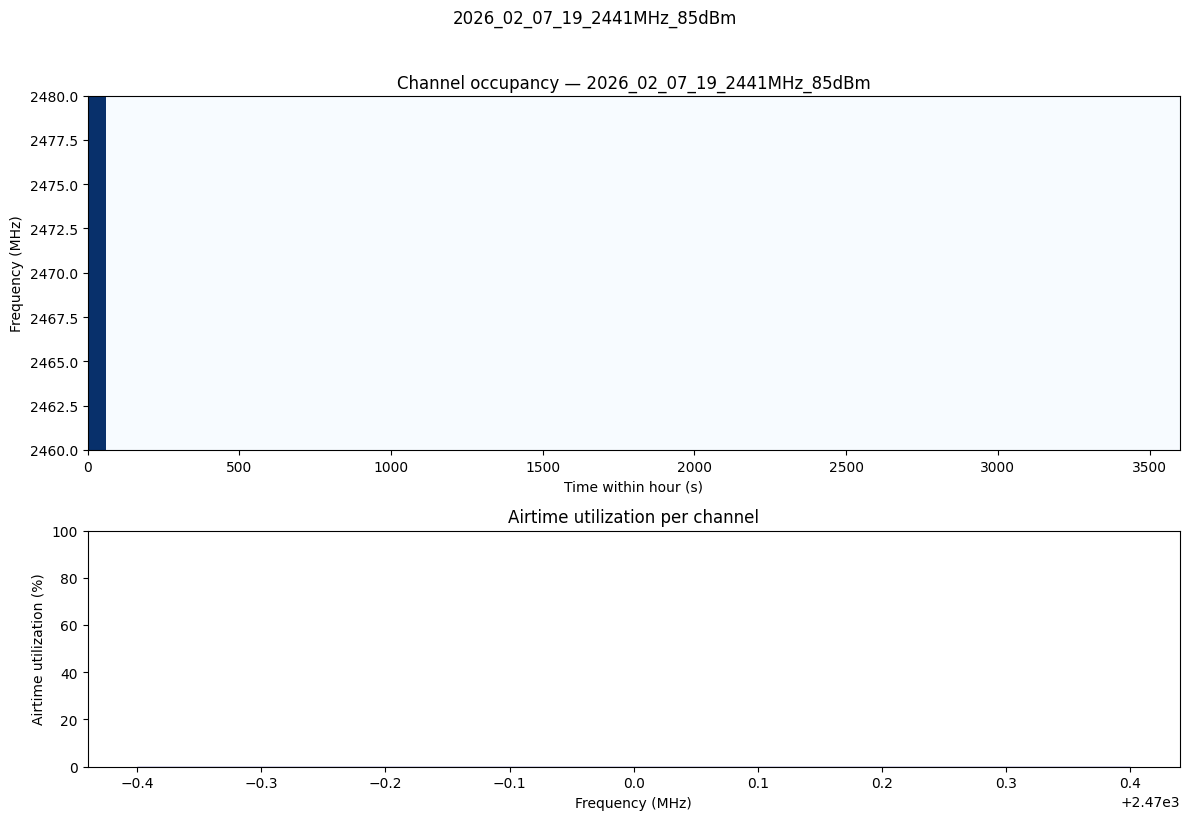

In [11]:
def _legend_base(p):
    """Legend path base from Data filename (Data_YYYY_MM_DD_HH_band_dBm.csv)."""
    m = re.match(r"Data_(\d{4}_\d{2}_\d{2})_(\d{2})_(\d+MHz)_.*\.csv", p.name, re.IGNORECASE)
    if m:
        date_part, hour, band = m.group(1), m.group(2), m.group(3)
        return f"{date_part}_{hour}_{band}"
    return None

for data_path in to_plot:
    try:
        df = pd.read_csv(data_path, header=None)
    except Exception as e:
        print(f"Skip {data_path.name}: {e}")
        continue
    if len(df) < 61:
        print(f"Skip {data_path.name}: too few rows")
        continue
    row0 = df.iloc[0].values
    n_col = len(row0)
    n_chans = n_col - 6
    if n_chans < 1:
        continue
    ts_start = row0[4]
    au_per_hour = np.asarray(row0[5 : 5 + n_chans])
    co_rows = df.iloc[1 : 61]
    time_bins = co_rows.iloc[:, 5].values
    co_ot = co_rows.iloc[:, 6 : 6 + n_chans].values

    base = _legend_base(data_path)
    legend_path = legend_dir / f"Legend_{base}.csv" if base else None
    if legend_path and legend_path.exists():
        leg = pd.read_csv(legend_path, header=None)
        freq_centers = ((leg.iloc[:, 1] + leg.iloc[:, 2]) / 2).values / 1e6
        freq_edges = np.concatenate([[leg.iloc[0, 1] / 1e6], leg.iloc[:, 2].values / 1e6])
    else:
        freq_centers = np.arange(n_chans, dtype=float)
        freq_edges = np.arange(n_chans + 1, dtype=float)

    time_sec = time_bins - ts_start
    t_edges = np.concatenate([time_sec, [time_sec[-1] + 60]])
    title_base = data_path.stem.replace("Data_", "")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[1.2, 0.8])
    ax1.pcolormesh(t_edges, freq_edges, co_ot.T, shading="flat", cmap="Blues", vmin=0, vmax=1)
    ax1.set_xlabel("Time within hour (s)")
    ax1.set_ylabel("Frequency (MHz)")
    ax1.set_title(f"Channel occupancy — {title_base}")

    w = (0.9 * (freq_centers[1] - freq_centers[0])) if len(freq_centers) > 1 else 0.8
    ax2.bar(freq_centers, au_per_hour, width=w, align="center", color="steelblue", edgecolor="navy", alpha=0.8)
    ax2.set_xlabel("Frequency (MHz)")
    ax2.set_ylabel("Airtime utilization (%)")
    ax2.set_title("Airtime utilization per channel")
    ax2.set_ylim(0, 100)
    plt.suptitle(title_base, y=1.02)
    plt.tight_layout()
    plt.show()

Each Data file gets one figure: **top** = channel occupancy over time (heatmap), **bottom** = airtime utilization (bar). Set `max_plots` in the second cell to limit how many figures are drawn (e.g. `24`); `None` = all files.

In [12]:
# (Plots are drawn in the loop above.)

In [13]:
# (Plots are drawn in the loop above.)